## Graph Data Generation, Analysis, and Efficiency Evaluation
In this part of the mini-project, you will develop a series of Python functions to **generate** and **analyze** **graph data**, and then **evaluate the runtime efficiency** of the functions you have written. This task is divided into three main parts:

1. Data Generation (Part 1) – You will write a function to generate and store graph data in a text (.txt) file.
2. Data Analysis (Part 2) – You will implement functions to analyze the graph data from the txt file.
3. Efficiency Evaluation (Part 3) – You will assess the runtime efficiency of your data analysis functions.

In [20]:
import matplotlib.pyplot as plt
import random
import string
import time
import os

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-xcv5zawq because the default path (/tmp/cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Part 1: Graph Data Generation  

In this section, you will implement a function to **generate** a text file containing graph data.  

- **`generateGraph`**: This function creates a list of edges, where each edge is represented as a pair of vertices. The edges are stored in a text file, with each edge written on a separate line. Each line consists of two vertex names (taken from a given list of strings), separated by a space.

##### Notes:  
Carefully follow the suggested `random` functions and the exact string formatting specified, as the autograder requires an exact match for both.  

To assist with debugging, several example files have been provided, and a helper function, `compareFiles()`, is available to help you identify any mismatched lines.  

Example files are located in the `example/` directory. Your output files will be saved in the `data/` directory by default, so you can compare them directly.


In [21]:
# INPUT:
# f1, a string containing the file path to the first file being compared
# f2, a string containing the file path to the second file being compared
# OUTPUT:
# A boolean (True) if the files are identical and (False) otherwise.
# It also prints the first line pair which is not identical after whitespace is stripped
def compareFiles(f1, f2):
    with open(f1, 'r') as myf1:
        with open(f2, 'r') as myf2:
            f1_line = myf1.readline().strip()
            f2_line = myf2.readline().strip()
            while f1_line or f2_line:
                if f1_line != f2_line:
                    print("F1: {}".format(f1_line))
                    print("F2: {}".format(f2_line))
                    return False
                f1_line = myf1.readline().strip()
                f2_line = myf2.readline().strip()
    return True

#compareFiles("example1.csv", "example1.csv")

In [22]:
#grade

# generateGraph
# Generates a text file containing a list of edges for a graph.
# Each edge consists of a pair of vertices selected from an input list of strings.
# The edges are written to the file, one per line, formatted as "start_vertex end_vertex" (space-separated).
#
# To ensure correct behavior with the autograder, edges should be created using random.sample(),
# which selects pairs of vertices without replacement (unlike random.choice(), which allows repetition).
#
# INPUT:
# - fname (str, required): The name of the text file to create (must end in .txt).
# - inList (list of str): A list of strings representing the vertices (nodes) of the graph.
# - edges (int, optional): The number of edges to generate. Default is 5.
# - seed (int, optional): A seed value for Python's random module to ensure reproducibility. Default is None.
#
# OUTPUT:
# - None. Instead, a text file is created at the specified path containing the generated edges.

def generateGraph(fname, inList=list(string.ascii_lowercase), edges=5, seed=None):
    if seed is not None:
        random.seed(seed)

    if len(inList) < 2:
        return

    # max_possible_edges = len(inList) * (len(inList) - 1) // 2
    # edges = min(edges, max_possible_edges)

    with open(fname, "w") as f:
        for _ in range(edges):
            v1, v2 = random.sample(inList, 2)
            f.write(f"{v1} {v2}\n")

In [23]:
# TEST generateGraph
# Compare with example/graph/...

generateGraph("data/graph/example1.txt", ["A", "B", "C","D"], seed=1)
generateGraph("data/graph/example2.txt", list(string.ascii_lowercase), 100, seed=5)

#### Part 2: Data Analysis  
You will implement two functions to **analyze** the graph data that you created in Part 1:  

- **`getNeighbors`**: Find and return a list of all neighboring vertices for a given input vertex.
- **`checkPathExists`**: Determine whether a specified path, given as a list of consecutive vertices, exists in the graph.

Unlike in part 1, you have much more freedom of design here -- you can use pandas, numpy, or built-in methods to read in and process your files. **Just be sure the code you are submitting is your own work and no one elses!** The functions you are implementing here are meant to review your Python fundamentals, not your ability to use chatGPT.

In [24]:
#grade

# getNeighbors
# Retrieves and returns a list of all neighboring vertices for a given input vertex.
# The function assumes that the input text file is formatted as an edge list, where:
# - Each line represents an undirected edge in the format: "<vertex1> <vertex2>".
# - Since edges are bidirectional, the entry "A B" means both A is connected to B and B is connected to A.
#
# INPUT:
# - fname (str, required): The name of the text file containing the edge list (must end in .txt).
# - inStr (str, required): The vertex for which neighbors should be found.
#
# OUTPUT:
# - A list of strings representing all unique neighbors of the input vertex.
# - If the input vertex has no neighbors, the function returns an empty list.

def getNeighbors(fname, inStr):
    neighbors = []
    
    with open(fname, "r") as f:
        for line in f:
            v1, v2 = line.strip().split()
            
            if v1 == inStr:
                neighbors.append(v2)
            
            if v2 == inStr:
                neighbors.append(v1)

    return list(set(neighbors))

In [25]:
print(getNeighbors("example/graph/example1.txt", "A")) # ['D', 'B']
print(getNeighbors("example/graph/example1.txt", "D")) # ['A', 'B']
print(getNeighbors("example/graph/example2.txt", "A")) # []
print(getNeighbors("example/graph/example2.txt", "a")) # ['h', 'g', 'o', 'i', 'e', 'm', 't', 'j', 'q']

['D', 'B']
['B', 'A']
[]
['e', 'i', 'q', 'o', 'g', 't', 'm', 'h', 'j']


In [26]:
#grade

# checkPathExists
# Determines whether a given path exists in the graph based on an edge list stored in a text file.
# The function assumes the input file is formatted as an edge list, where:
# The function checks if the sequence of vertices provided in `inList` forms a valid connected path.
#
# INPUT:
# - fname (str, required): The name of the text file containing the edge list.
# - inList (list of str, required): A list of vertices representing the path to check.
#
# OUTPUT:
# - A boolean value:
#   - True if the path exists, meaning each consecutive pair of vertices in `inList` has a direct edge.
#   - False if at least one pair of consecutive vertices is not directly connected in the graph.


def checkPathExists(fname, inList):
    edges = set()
    
    with open(fname, "r") as f:
        for line in f:
            v1, v2 = line.strip().split()
            edges.add((v1, v2))
            edges.add((v2, v1))

    for i in range(len(inList) - 1):
        if (inList[i], inList[i + 1]) not in edges:
            return False

    return True

In [27]:
print(checkPathExists("example/graph/example1.txt", ["A", "C"])) # False
print(checkPathExists("example/graph/example1.txt",["A", "B", "C", "D"])) # False 
print(checkPathExists("example/graph/example1.txt",["A", "B", "D"])) # True
print(checkPathExists("example/graph/example2.txt", ["a", "j", "t"])) # False
print(checkPathExists("example/graph/example2.txt", ["a", "j", "k"])) # True

False
False
True
False
True


#### Part 3: Runtime Efficiency Evaluation  

In this part, you will evaluate the runtime efficiency of the `checkPathExists` function from Part 2. You **must** complete Part 2 and pass the autograder before starting this part. Unlike previous parts, this section **will not be autograded** but will be **graded manually**.  

##### **Instructions**  

1. **Generate Graph Data**  
   - Re-run the `checkPathExists` function with different values of `edges` (e.g., `10, 100, 1000, 5000`).  
   - **Ensure that `edges` does not exceed 500,000**, as PrairieLearn has limited storage capacity.  

2. **Measure Runtime Performance**  
   - For each experiment (one function run with a different `edges` value):  
     - Generate a text file using `generateGraph`.  
     - Process the generated graph data using `checkPathExists`.  
     - Record the function’s runtime and the corresponding `edges` value.  

3. **Plot and Submit Results**  
   - Store the recorded runtime values and `edges` values in two lists.  
   - Plot the relationship between `edges` and runtime.  
   - Download the plot (as a PNG image) to your local computer.  
   - Upload the image to the **Part 3 submission folder** for grading.

In [39]:
# evaluateRuntime: Evaluates the runtime of the checkPathExists function for different value of edges.

# INPUT:
# edges (list of int): A list of edge values to test.
# fname (str, optional): The name of the txt file to be generated and tested. Default is "test_file.txt".
# inList (str, optional): The path to search for in the generated graph data. Default is ['a', 'b', 'c'].

# OUTPUT:
# List of edges values used in the experiments.
# Corresponding runtimes (in seconds) for each edges value.

def evaluateRuntime(edges, fname="test_file.txt", inList=["a", "b", "c"]):
    runtimes = []
    
    for edge in edges:
        generateGraph(fname, inList, edge)
        
        start = time.time()
        checkPathExists(fname, inList)
        end = time.time()       

        runtime = end - start
        runtimes.append(runtime) 
        
    return edges, runtimes 

In [40]:
# TEST evaluateRuntime
edges = [10000, 30000, 50000, 70000, 90000]
edges_used, runtimes = evaluateRuntime(edges, fname="test_file.txt", inList=["a", "b", "c"])

In [41]:
def plotRuntime(edges_used, runtimes):
    plt.figure(figsize=(10, 5))
    plt.plot(edges_used, runtimes, marker="o", linestyle="-", label="Runtime (seconds)")

    plt.xlabel("Number of edges")
    plt.ylabel("Execution Time (seconds)")
    plt.title("Runtime of checkPathExists")
    plt.legend()

    plt.savefig("runtime_plot_graph.png")

    plt.show()

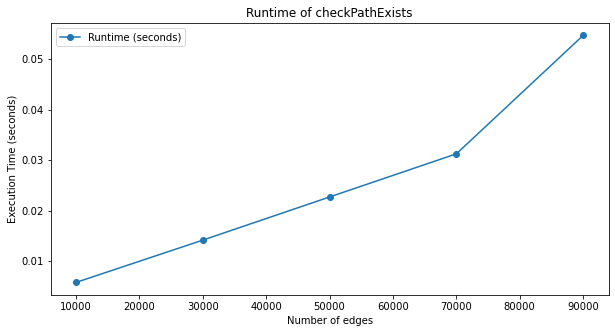

In [42]:
# TEST plotRuntime and SAVE PLOT
plotRuntime(edges_used, runtimes)